# NB06 — SHAP Explainability
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251

---

**Purpose:** Deconstruct the "black box" of the best-performing machine learning model using SHapley Additive exPlanations (SHAP). We extract stage-specific biomarkers by evaluating SHAP values *independently per class*. This identifies exactly which genes push the prediction towards or away from Healthy, Steatosis, NASH, and Advanced Fibrosis.

**CRITICAL RULE:** SHAP values must be computed and visualized per class. Global summary plots are only supplementary.

**Outputs:**
- `results/models/shap_values_class{k}.npy` (×4)
- `results/tables/top_shap_genes_per_class.csv`
- `results/figures/shap_per_class_barplot.png`
- `results/figures/shap_global_beeswarm.png`


## 1. Install Dependencies

In [27]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "xgboost",
    "shap",
    "matplotlib",
    "seaborn",
    "joblib"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"]
    )

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration & Imports

In [28]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# ── CONFIGURATION ─────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
RESULTS_TAB  = PROJECT_ROOT / "results" / "tables"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"
RESULTS_MOD  = PROJECT_ROOT / "results" / "models"

CLASS_NAMES = ["Healthy", "Steatosis", "NASH", "Adv. Fibrosis"]


## 3. Load Data & Model

In [29]:
# We will evaluate both top models for comparison
models_to_evaluate = ['xgboost']

# Load full preprocessed expression matrix
expr_path = DATA_PROC / "expression_preprocessed.csv"
expr_df = pd.read_csv(expr_path, index_col=0)
X_full = expr_df.T

# Load labels
meta_path = DATA_META / "labeled_metadata.csv"
meta_df = pd.read_csv(meta_path).set_index("sample_id")

# Align
shared_samples = X_full.index.intersection(meta_df.index)
X_full = X_full.loc[shared_samples]
y = meta_df.loc[shared_samples, "nafld_stage"].astype(int)

print(f"Data shape for SHAP analysis: {X_full.shape}")


Data shape for SHAP analysis: (216, 42584)


## 4. Compute Multi-Class SHAP Values

In [30]:
print("Computing SHAP values for both models... this may take a moment.")

shap_values_dict = {}
X_dict = {}

for model_name in models_to_evaluate:
    print(f"\n--- Processing {model_name} ---")
    model_path = RESULTS_MOD / f"{model_name}_model.pkl"
    model = joblib.load(model_path)
    
    if hasattr(model, "feature_names_in_"):
        model_features = model.feature_names_in_
    else:
        model_features = model.steps[-1][1].feature_names_in_
        
    X = X_full[model_features]
    X_dict[model_name] = X
    
    try:
        if model_name == 'xgboost' or 'xgb' in model_name:
            if hasattr(model, 'named_steps') and 'xgb' in model.named_steps:
                xgb_model = model.named_steps['xgb']
            else:
                xgb_model = model
            explainer = shap.TreeExplainer(xgb_model)
            shap_values = explainer.shap_values(X)
        else:
            explainer = shap.KernelExplainer(lambda x: model.predict_proba(x), shap.sample(X, 50))
            shap_values = explainer.shap_values(X)
    except Exception as e:
        print(f"Explainer failed: {e}. Falling back to KernelExplainer.")
        explainer = shap.KernelExplainer(lambda x: model.predict_proba(x), shap.sample(X, 50))
        shap_values = explainer.shap_values(X)

    if hasattr(shap_values, "values"):
        shap_values = shap_values.values
        
    if isinstance(shap_values, np.ndarray):
        if len(shap_values.shape) == 3:
            if shap_values.shape[2] == len(CLASS_NAMES):
                shap_values = [shap_values[:, :, i] for i in range(len(CLASS_NAMES))]
            elif shap_values.shape[0] == len(CLASS_NAMES):
                shap_values = [shap_values[i, :, :] for i in range(len(CLASS_NAMES))]

    assert isinstance(shap_values, list), f"shap_values must be a list"
    assert len(shap_values) == 4, f"Expected 4 class arrays, got {len(shap_values)}"
    assert shap_values[0].shape == X.shape, f"Shape mismatch: {shap_values[0].shape} vs {X.shape}"

    shap_values_dict[model_name] = shap_values
    
    for i, class_name in enumerate(CLASS_NAMES):
        out_path = RESULTS_MOD / f"{model_name}_shap_values_class{i}.npy"
        np.save(out_path, shap_values[i])
        print(f"Saved SHAP values for {class_name} to {out_path.name}")


Computing SHAP values for both models... this may take a moment.

--- Processing xgboost ---
Saved SHAP values for Healthy to xgboost_shap_values_class0.npy
Saved SHAP values for Steatosis to xgboost_shap_values_class1.npy
Saved SHAP values for NASH to xgboost_shap_values_class2.npy
Saved SHAP values for Adv. Fibrosis to xgboost_shap_values_class3.npy


## 5. Per-Class Stage-Specific Biomarker Extraction

In [31]:
# Compute mean absolute SHAP for each class
top_genes_per_class = []

for model_name in models_to_evaluate:
    shap_values = shap_values_dict[model_name]
    X = X_dict[model_name]
    for k, class_name in enumerate(CLASS_NAMES):
        sv_k = shap_values[k]
        mean_abs_shap = np.abs(sv_k).mean(axis=0)
        mean_signed_shap = sv_k.mean(axis=0)
        
        # Create DF
        class_df = pd.DataFrame({
            'model': model_name,
            'class_id': k,
            'class_name': class_name,
            'gene': X.columns,
            'mean_abs_shap': mean_abs_shap,
            'mean_signed_shap': mean_signed_shap
        })
        
        # Sort and rank
        class_df = class_df.sort_values(by='mean_abs_shap', ascending=False)
        class_df['rank'] = np.arange(1, len(class_df) + 1)
        
        # Direction
        class_df['direction'] = class_df['mean_signed_shap'].apply(lambda x: 'Positive (Pushes towards)' if x > 0 else 'Negative (Pushes away)')
        
        top_genes_per_class.append(class_df.head(50)) # Save top 50 per class

final_shap_df = pd.concat(top_genes_per_class, ignore_index=True)
csv_path = RESULTS_TAB / "top_shap_genes_per_class.csv"
final_shap_df.to_csv(csv_path, index=False)
print(f"Saved stage-specific biomarkers to: {csv_path}")


Saved stage-specific biomarkers to: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\top_shap_genes_per_class.csv


## 6. Visualize Top Biomarkers per Stage

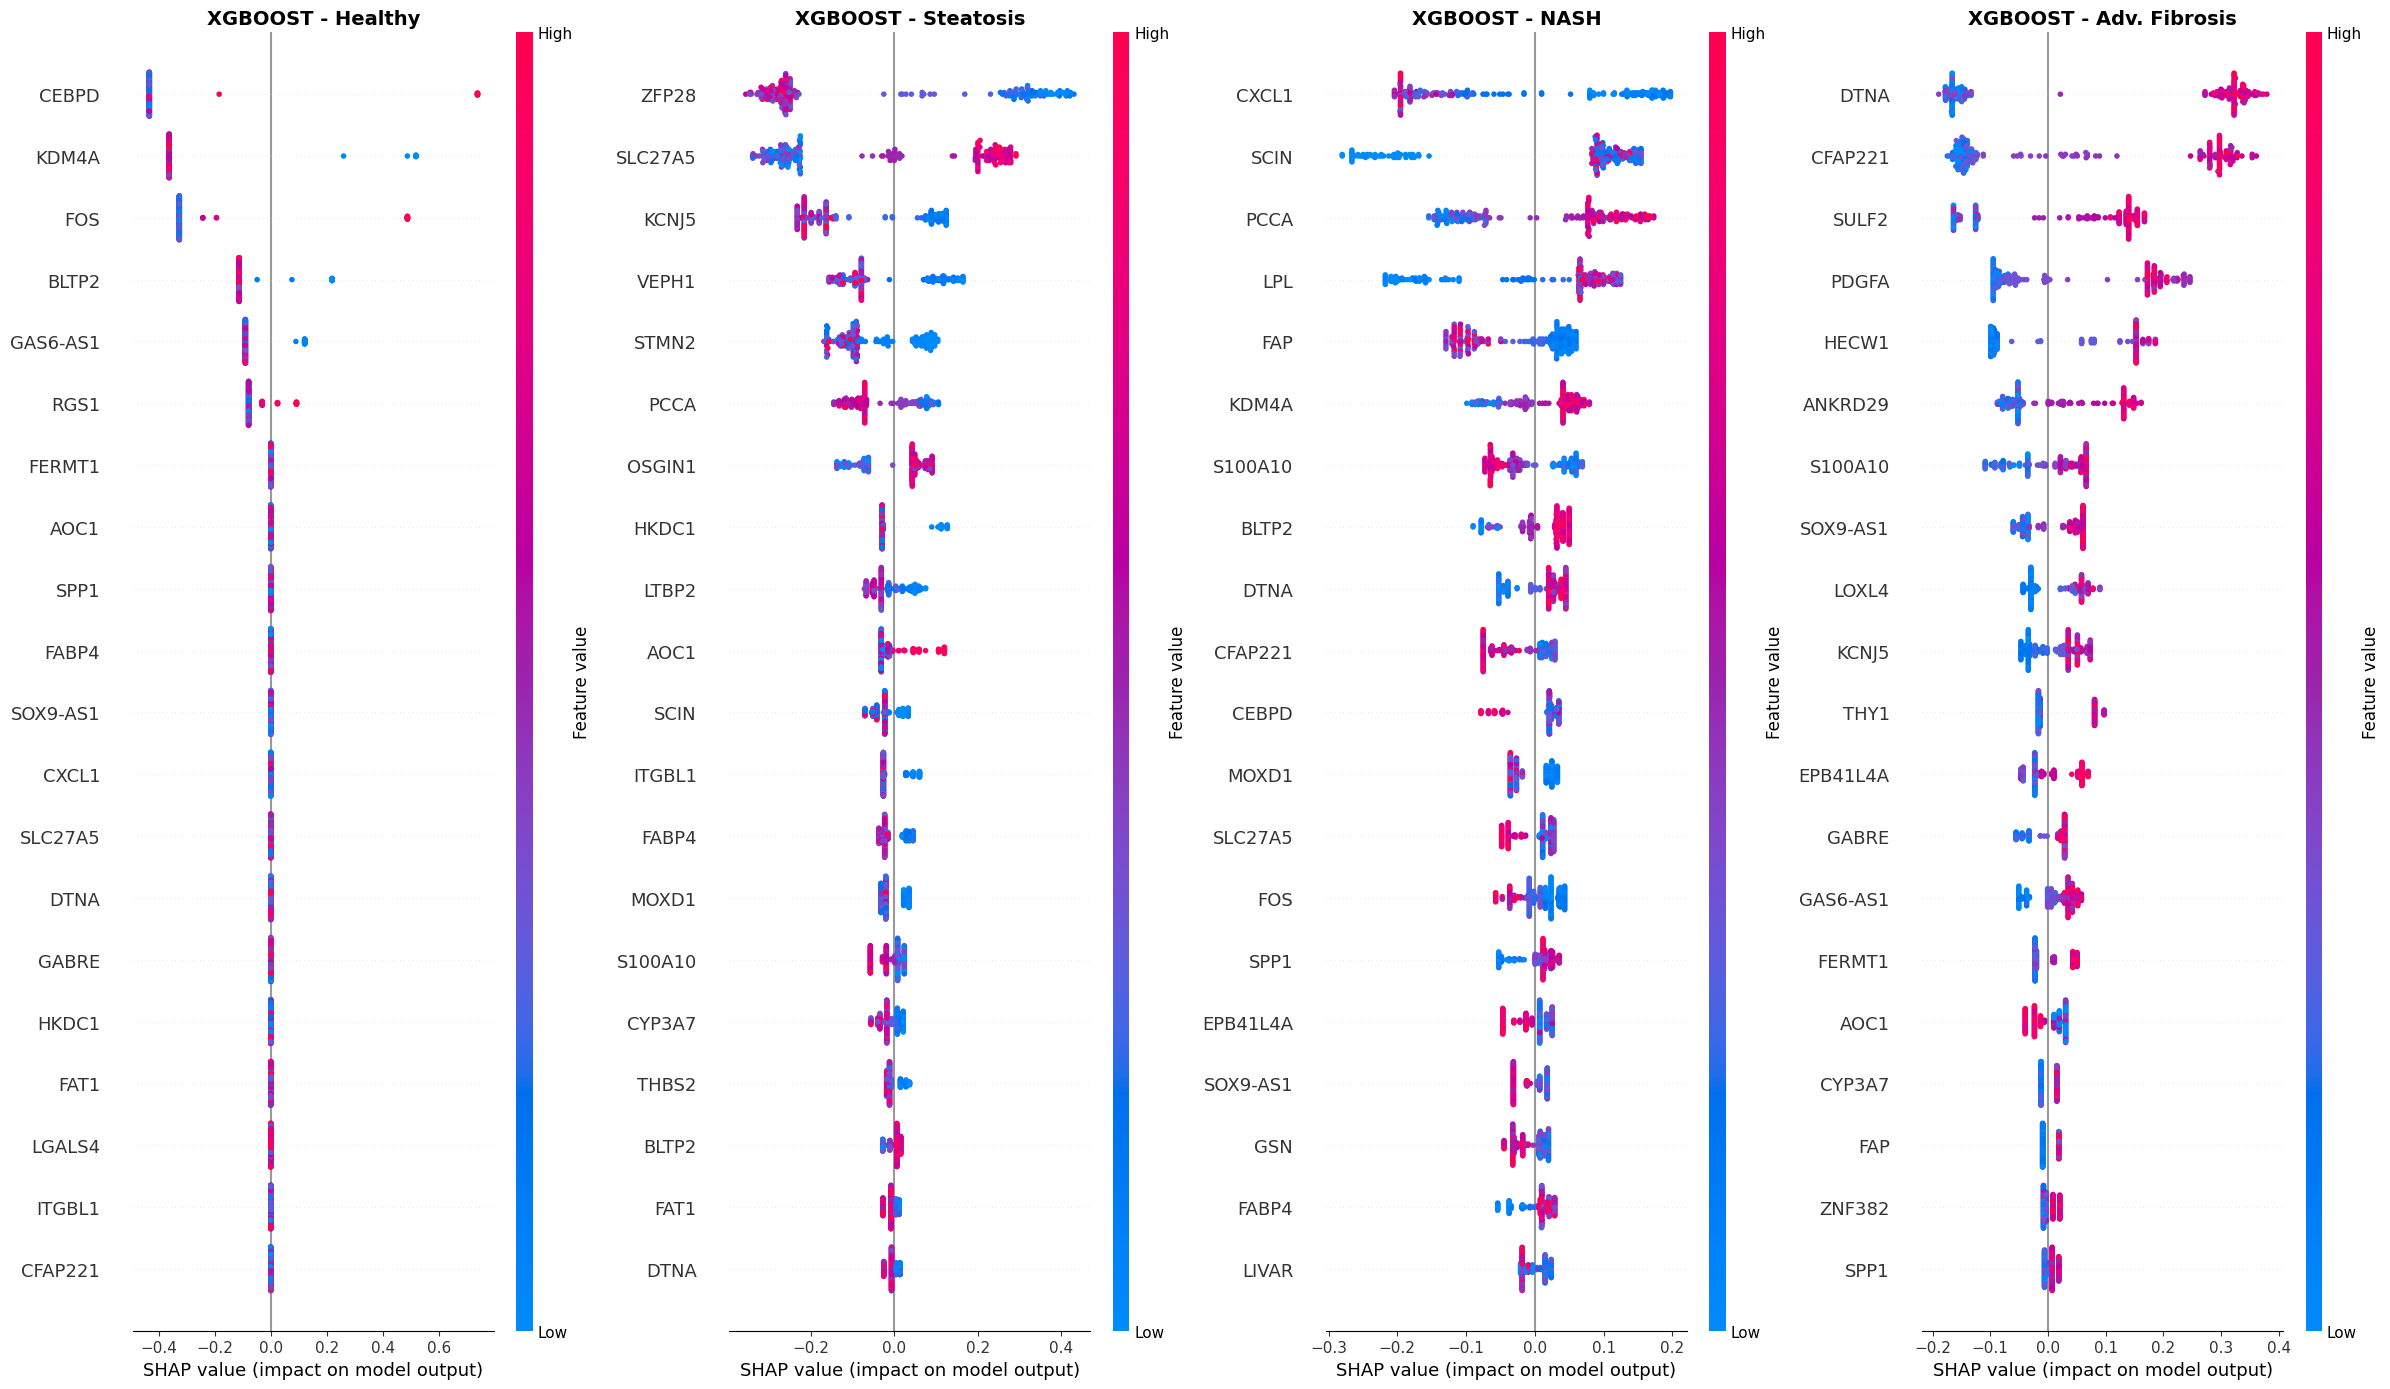

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig6_shap_per_class_beeswarm.png


In [32]:
# ### Fig 6 - SHAP Beeswarm Plots (Stage-Specific) Comparative
# Top 20 genes per class showing both magnitude and direction of impact.

fig = plt.figure(figsize=(24, 14))
plot_idx = 1
for model_name in models_to_evaluate:
    shap_values = shap_values_dict[model_name]
    X = X_dict[model_name]
    for k, class_name in enumerate(CLASS_NAMES):
        plt.subplot(len(models_to_evaluate), len(CLASS_NAMES), plot_idx)
        # Get top genes for this class to limit the beeswarm
        class_data = final_shap_df[(final_shap_df['class_id'] == k) & (final_shap_df['model'] == model_name)].head(20)
        top_genes_k = class_data['gene'].tolist()
        X_k = X[top_genes_k]
        sv_k = shap_values[k][:, [X.columns.get_loc(g) for g in top_genes_k]]
        
        shap.summary_plot(sv_k, X_k, show=False, plot_size=None)
        plt.title(f"{model_name.upper()} - {class_name}", fontsize=14, fontweight='bold')
        plot_idx += 1

plt.tight_layout()
fig_path = RESULTS_FIG / "fig6_shap_per_class_beeswarm.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


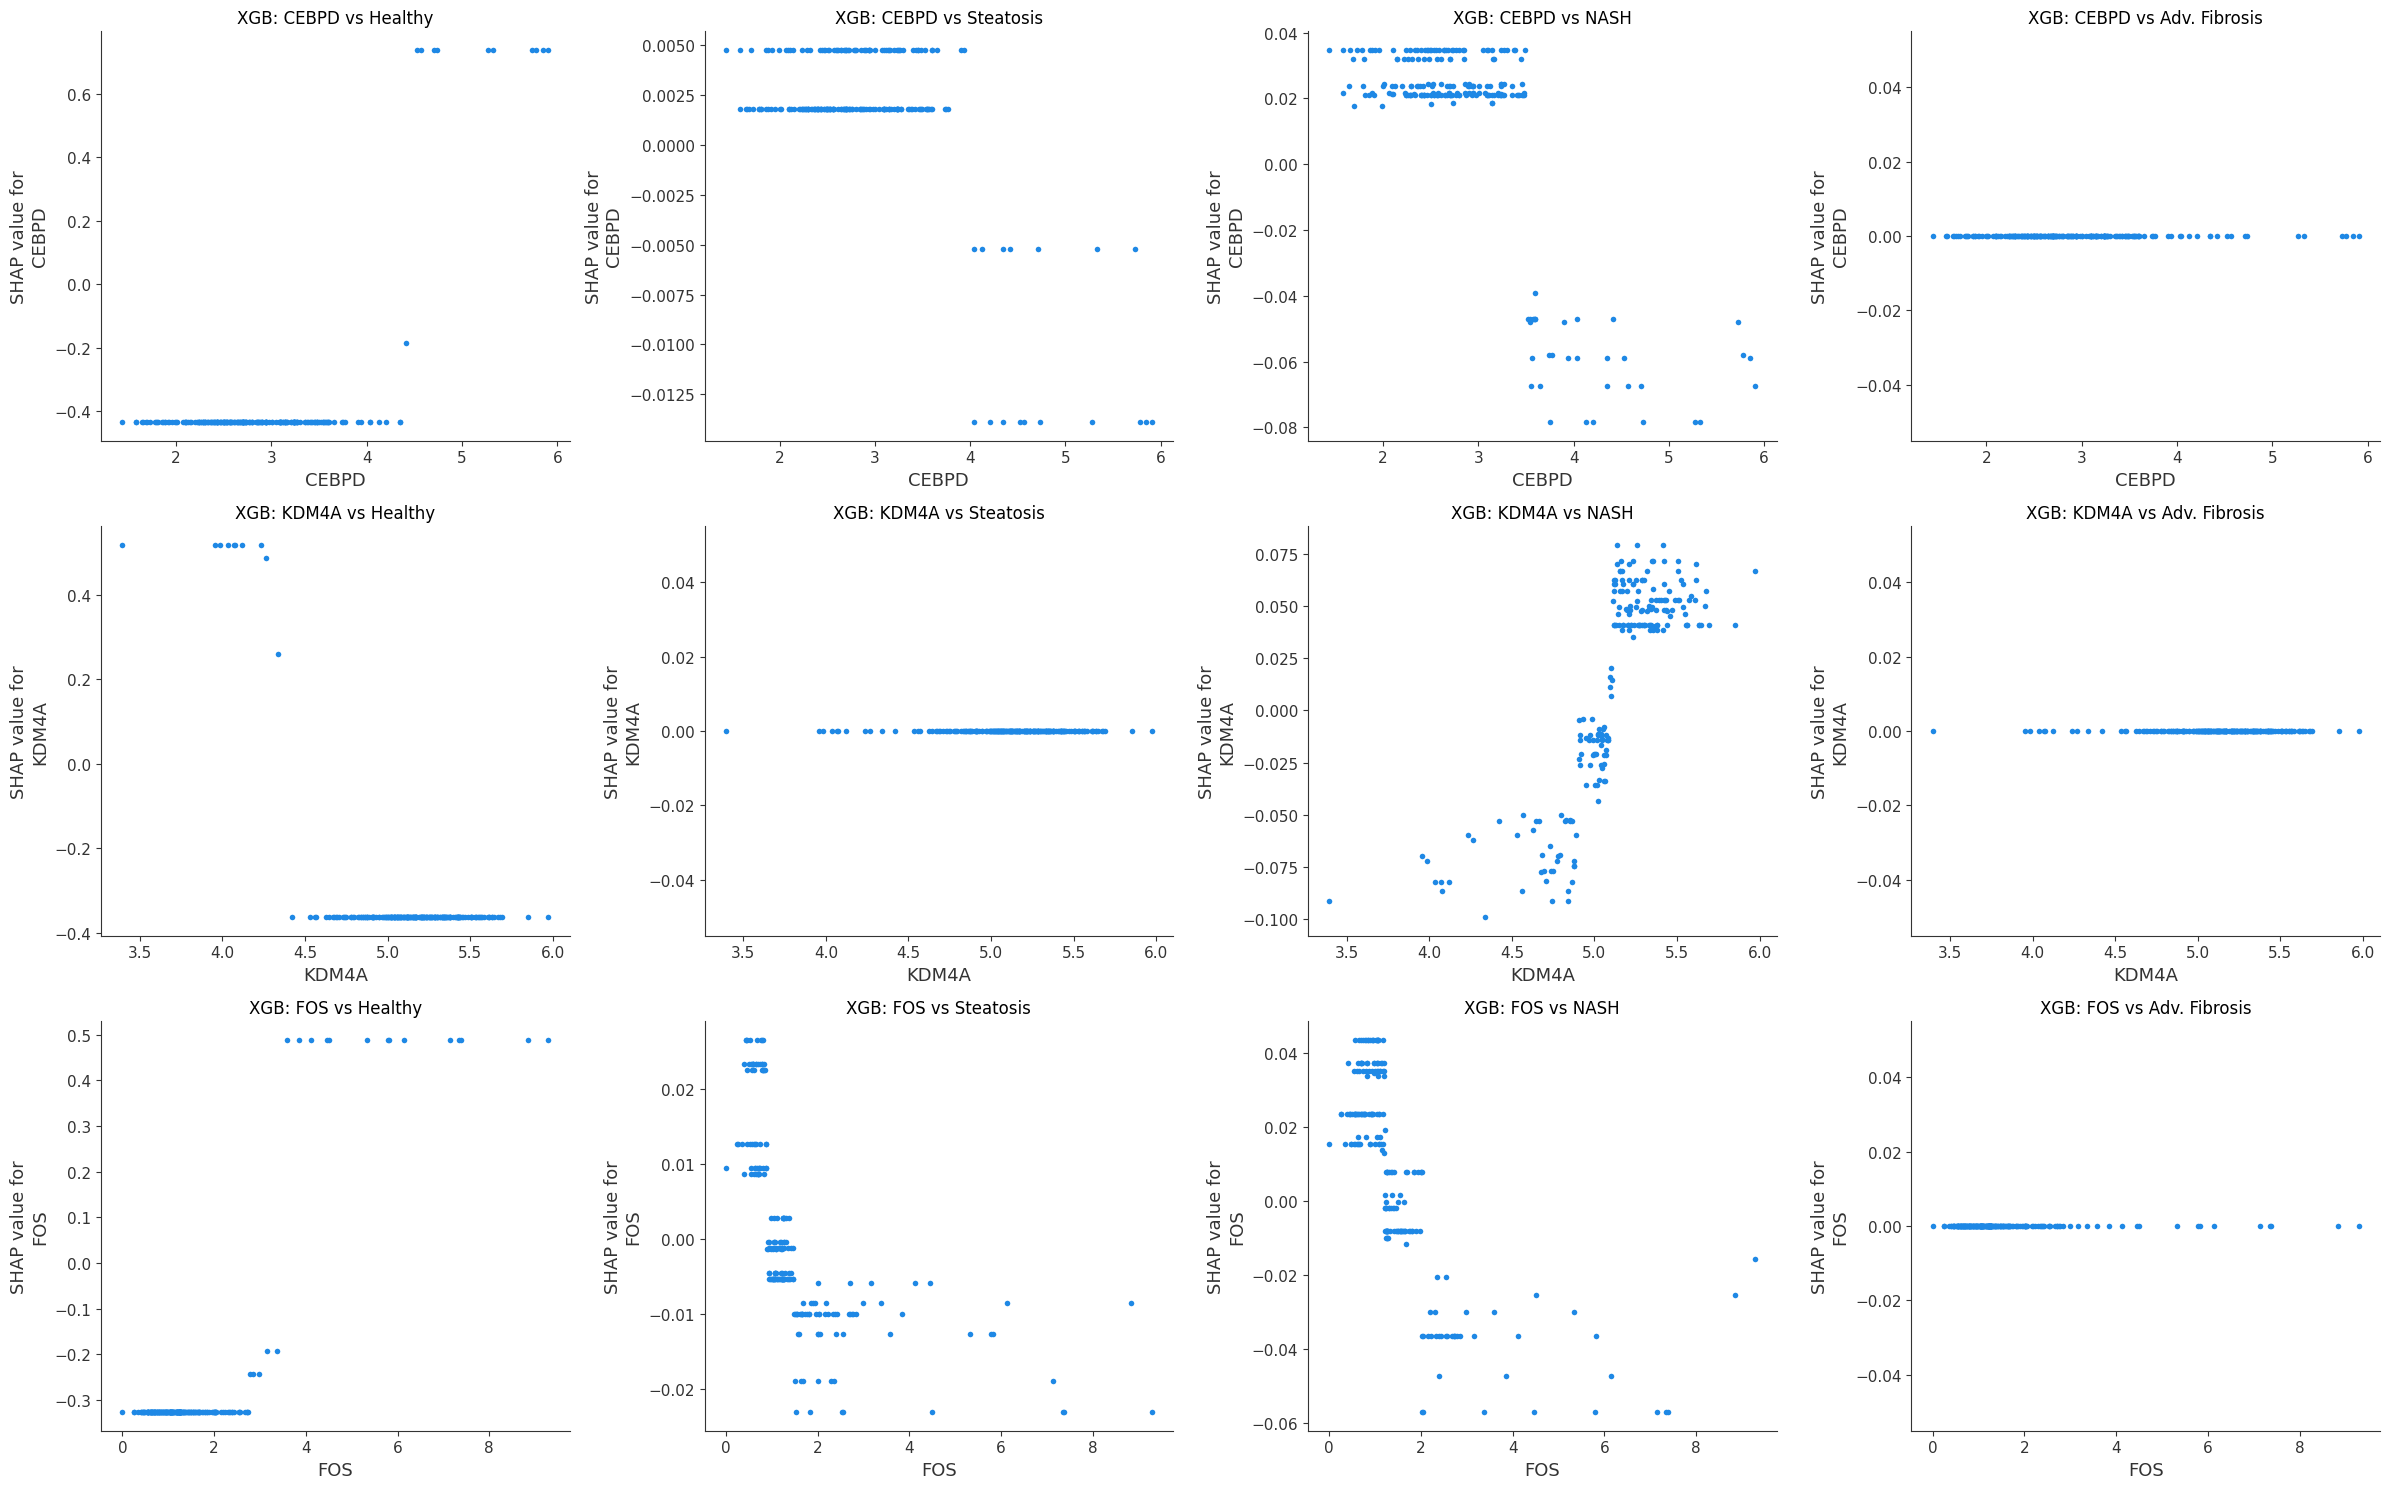

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig9_shap_dependence_plots.png


In [33]:
# ### Fig 9 - SHAP Dependence Plots (Top 3 Genes)
# Shows how gene expression level (X-axis) relates to the SHAP value (Y-axis).
# We'll do this for XGBoost specifically as dependence plots are most often used for tree models.

if 'xgboost' in models_to_evaluate:
    shap_values_xgb = shap_values_dict['xgboost']
    X_xgb = X_dict['xgboost']
    global_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_xgb], axis=0)
    top_3_idx = np.argsort(global_importance)[-3:][::-1]
    top_3_genes = X_xgb.columns[top_3_idx].tolist()

    fig, axes = plt.subplots(3, 4, figsize=(24, 15))

    for i, gene in enumerate(top_3_genes):
        for k, class_name in enumerate(CLASS_NAMES):
            ax = axes[i, k]
            # Use shap.dependence_plot
            shap.dependence_plot(gene, shap_values_xgb[k], X_xgb, ax=ax, show=False, interaction_index=None)
            ax.set_title(f"XGB: {gene} vs {class_name}", fontsize=12)

    plt.tight_layout()
    fig_path = RESULTS_FIG / "fig9_shap_dependence_plots.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("XGBoost model not found, skipping dependence plots.")


## 7. Global Summary (Supplementary)

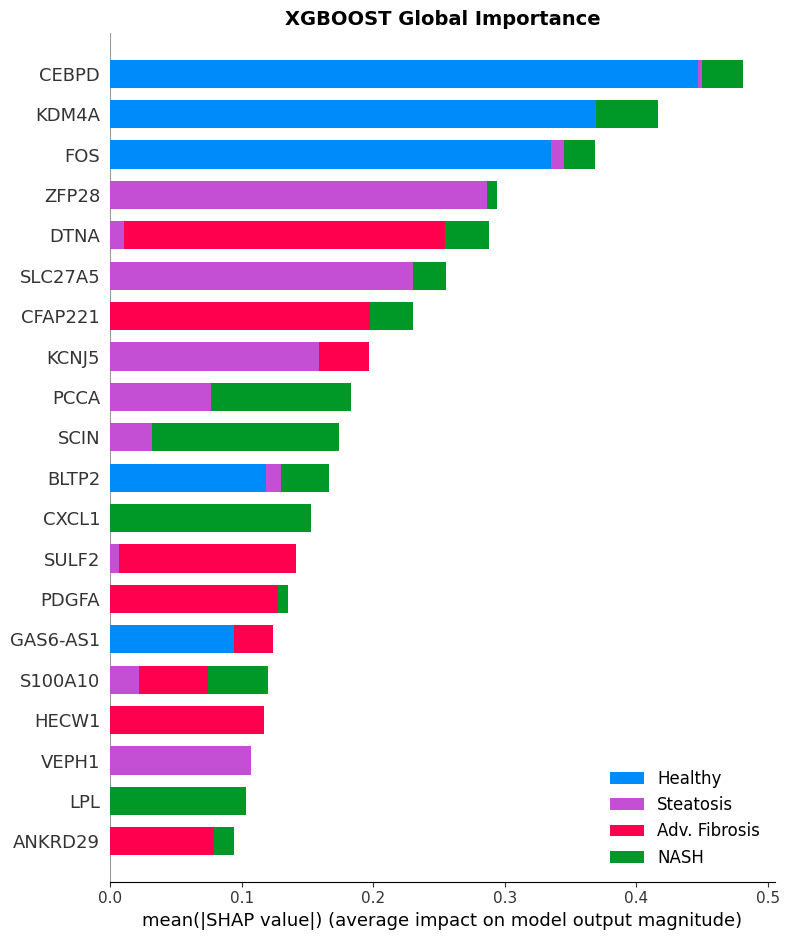

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\shap_global_summary.png


In [34]:
# Global bar plot comparison (mean of means)

fig, axes = plt.subplots(1, len(models_to_evaluate), figsize=(18, 8))

for i, model_name in enumerate(models_to_evaluate):
    ax = axes[i] if len(models_to_evaluate) > 1 else axes
    plt.sca(ax)
    shap_values = shap_values_dict[model_name]
    X = X_dict[model_name]
    
    shap.summary_plot(shap_values, X, plot_type="bar", class_names=CLASS_NAMES, show=False)
    ax.set_title(f"{model_name.upper()} Global Importance", fontsize=14, fontweight='bold')

plt.tight_layout()
fig_path = RESULTS_FIG / "shap_global_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
